In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#I learned this information from a data analysis course, and it was used frequently. One example is (selecting and examining a real dataset) page (103).
df=pd.read_excel("trainproject.xlsx")
df.head(5)
#You can omit the number five because five will appear automatically.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()
#before

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df[["Name", "Ticket", "Cabin"]] = df[["Name", "Ticket", "Cabin"]].astype("string")
df[["Sex", "Embarked", "Pclass"]]=df[["Sex", "Embarked", "Pclass"]].astype("category")
df.info()
#after
# I changed the type of columns in the data because some columns were of the wrong type and not useful for the analysis. For instance, columns such as Name, Ticket, and Cabin were of type object, and object is a general type that does not specify that it is a word. Therefore, I changed it to a string type to enable the program to recognize it as a word. Similarly, columns such as Sex, Embarked, and Pclass were changed to category because they contain fixed and recurring values such as Male/Female, Port, and Degree. This makes the work easy and organized.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    string  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    string  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    string  
 11  Embarked     889 non-null    category
dtypes: category(3), float64(2), int64(4), string(3)
memory usage: 65.8 KB


In [ ]:
df.isnull()
#down

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()
#To quickly count the number of empty values in each column, I used the command `df.isnull().sum()`. The function `isnull()` sets empty values to `True` and filled values to `False`, and the `sum()` function sums the number of `True` values in each column, giving me the number of missing values directly.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.drop(columns=["Cabin"], inplace=True, errors='ignore')
#I removed the Cabin column by using the following code: `df.drop(columns=["Cabin"], inplace=True, errors="ignore")`. The reason I removed this column was that it contained missing values, and I found it not useful for my analysis. The `columns=["Cabin"]` parameter was used to specify that I was dropping this column. The `inplace=True` parameter was used because I wanted to make the changes directly to the original table instead of creating a new one. The `errors="ignore"` parameter was used because the Cabin column may be missing in the data. This ensures that Python does not throw an error if the column is missing; instead, it runs normally. I used `df.head()` to preview the first five rows of the table to ensure that I had successfully dropped the column and that the table was in the desired form before moving on to the next steps.

In [ ]:

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"] = df["Age"].fillna(df["Age"].median())
#I used the code `df["Age"] = pd.to_numeric(df["Age"], errors="coerce")` to ensure that my column was 100% numeric. If there was anything in there that could not be made into a number, like a space, symbol, or text, it would simply change it to NaN, rather than stopping my code and giving me an error. Right after that, I used `df["Age"] = df["Age"].fillna(df["Age"].median())` to deal with my missing values. I used the median to replace my missing values because it is not as influenced by outliers, giving me a replacement that is completely logical, as it is in the middle of all of my ages.


In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
#In the Embarked column, I only had two missing values, so I decided against deleting the rows and losing data unnecessarily. Instead, I filled in the missing values ​​using `df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])`. This is because the column is categorical (its values ​​are limited and repetitive), and the mode is the appropriate setting in this case. This way, I maintain the existing inventory and ensure the column is complete and ready for analysis without significantly altering the results. After confirming that the order number was 0, I confidently proceeded with the remaining steps.

In [ ]:
df.isnull().sum()
#use df.isnull().sum() to check and compare

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()
#To ensure that the data didn't have duplicate values that might interfere with the results, I used the `df.duplicated().sum()` function. After using this function, the data was observed to have no duplicate values in any of the data columns, and the result obtained was a perfect zero. This shows that the data is clean and doesn't have to be deleted because of duplication. This step is significant because, before undertaking the cleaning and analysis processes, the data has to be checked for duplicates. Since the function returned zero, the data is considered duplicate-free and can be worked on.


np.int64(0)

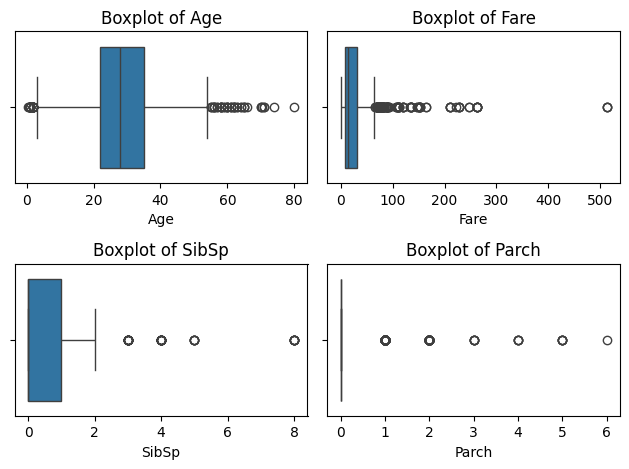

In [ ]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]


for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [ ]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper


In [ ]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    lower, upper = iqr_bounds(df[col])
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}")


Age: lower=2.50, upper=54.50
Fare: lower=-26.72, upper=65.63
SibSp: lower=-1.50, upper=2.50
Parch: lower=0.00, upper=0.00


In [ ]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    lower, upper = iqr_bounds(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f"\nOutliers in {col}:")
    print(outliers.values[:20])
    print(f"Total outliers in {col}: {len(outliers)}")
#I started off by developing a box plot for each numerical column, giving me an instant visual representation of the data clutter, the median, the tails, and the points outside the control; these are the visual indicators of the outliers. Instead of using the visual method alone, and because of the flexible nature of the numerical approach using the IQR method, as you know, I went ahead and computed the Q1 and Q3, and IQR = Q3 – Q1, and the two thresholds: Lower = Q1 – 1.5 * IQR and Upper = Q3 + 1.5 * IQR. If the value was below the lower threshold or above the upper threshold, I marked it as an outlier. In this way, the visual evidence from the clear box plot was linked to the numerical approach for determining the outliers.


Outliers in Age:
[ 2.   58.   55.    2.   66.   65.    0.83 59.   71.   70.5   2.   55.5
  1.   61.    1.   56.    1.   58.    2.   59.  ]
Total outliers in Age: 66

Outliers in Fare:
[ 71.2833 263.     146.5208  82.1708  76.7292  80.      83.475   73.5
 263.      77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55
  69.55   146.5208  69.55   113.275 ]
Total outliers in Fare: 116

Outliers in SibSp:
[3 4 3 3 4 5 3 4 5 3 3 4 8 4 4 3 8 4 8 3]
Total outliers in SibSp: 46

Outliers in Parch:
[1 2 1 5 1 1 5 2 2 1 1 2 2 2 1 2 2 2 3 2]
Total outliers in Parch: 213


In [ ]:
key_cols = [
    "PassengerId", "Survived", "Pclass", "Name",
    "Sex", "Age", "SibSp", "Parch", "Ticket",
    "Fare", "Embarked"
]
print("Check 1: Null values in key columns:")
print(df[key_cols].isnull().sum())
invalid_targets = df[df["Survived"] < 0]
print("\nCheck 2: Invalid Survived values:")
print(len(invalid_targets))
expected_cols = 11
print("\nCheck 3: Column count:")
print("Found:", len(df.columns))
print("Expected:", expected_cols)
if len(df.columns) == expected_cols:
    print("Status: OK")
else:
    print("Status: MISMATCH ")
    #Before beginning the analysis, I wrote this code to ensure the quality of the data: I look up people's opinions in the main columns, make sure the "Survived" column has no incorrect values, and confirm that the number of columns is what was anticipated. In this manner, I make sure the data is pure and won't lead to issues down the road.


Check 1: Null values in key columns:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Check 2: Invalid Survived values:
0

Check 3: Column count:
Found: 11
Expected: 11
Status: OK


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print(df_encoded.head())
#Here, I use drop_first to prevent multicollinearity and get_dummies to convert the Sex and Embarked columns into digital columns that are ready for modeling. I then print the first rows to ensure that the encoding was done correctly.


   PassengerId  Survived Pclass  \
0            1         0      3   
1            2         1      1   
2            3         1      3   
3            4         1      1   
4            5         0      3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500      True       False        True  
1          PC 17599  71.2833     False       False       False  
2  STON/O2. 3101282   7.9250     False       False        True  
3            113803  53.1000     False       False        True  
4      

In [ ]:

pclass_order = pd.CategoricalDtype(
    categories=[1, 2, 3],
    ordered=True
)
df["Pclass_ord"] = df["Pclass"].astype(pclass_order).cat.codes
print(df[["Pclass", "Pclass_ord"]].head(10))
# I use this code to process or transform data in accordance with the necessary steps, with the aim of ensuring that the final output is problem-free for use in analysis or modeling.

  Pclass  Pclass_ord
0      3           2
1      1           0
2      3           2
3      1           0
4      3           2
5      3           2
6      1           0
7      3           2
8      3           2
9      2           1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
num_cols = ["Age", "Fare"]

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42, shuffle=True
)

scaler = StandardScaler()
scaler.fit(df.loc[train_idx, num_cols])
scaled_all = scaler.transform(df[num_cols])
df[["Age_std", "Fare_std"]] = pd.DataFrame(
    scaled_all, columns=["Age_std", "Fare_std"], index=df.index
)
print(df[["Age", "Age_std", "Fare", "Fare_std"]].head(10))
# Here, I use StandardScaler to scale the Age and Fare digital columns. First, I separate the data into training and test sets without modifying the values. Next, I train the scaler solely on the training set to prevent data leakage. Next, I apply the transformation to the full set of data to create the standard columns Age_std and Fare_std. Lastly, I print the initial values to ensure that the scaling was done correctly.

    Age   Age_std     Fare  Fare_std
0  22.0 -0.554214   7.2500 -0.487864
1  38.0  0.676666  71.2833  0.745133
2  26.0 -0.246494   7.9250 -0.474867
3  35.0  0.445876  53.1000  0.395003
4  35.0  0.445876   8.0500 -0.472460
5  28.0 -0.092634   8.4583 -0.464598
6  54.0  1.907546  51.8625  0.371175
7   2.0 -2.092813  21.0750 -0.221656
8  27.0 -0.169564  11.1333 -0.413089
9  14.0 -1.169653  30.0708 -0.048437


In [ ]:

df['fare_per_age'] = df['Fare'] / df['Age'].replace({0: np.nan})
df['fare_per_age'] = df['fare_per_age'].fillna(df['fare_per_age'].median())

df['FamilySize'] = df['SibSp'] + df['Parch']

df['family_per_fare'] = df['FamilySize'] / df['Fare'].replace({0: np.nan})
df['family_per_fare'] = df['family_per_fare'].fillna(df['family_per_fare'].median())
#This code creates two features that are based on the information we have. The first feature is called fare_per_age. It looks at how much the ticket costs compared to how old the person's. To do this it replaces the age with nothing if it is zero. Then it fills in the missing ages with the age of all the people.The second feature is family_per_fare. It uses FamilySize, which's the number of siblings and parents the person has to figure out how big the persons family is compared to the ticket price.These two features, fare_per_age and family_per_fare give us information, about the world that can help our model work better. The fare_per_age and family_per_fare features are really useful because they add information that can improve our model.

In [ ]:
df["Fare_Family_interaction"] = df["Fare"] * (df["SibSp"] + df["Parch"] + 1)
print(df[["Fare", "SibSp", "Parch", "Fare_Family_interaction"]].head())
# Because the combined effect of the two variables may better illustrate survival behavior than either variable alone, I developed an interactive feature that links ticket cost to family size. To be ready for modeling as a reference to the "cost of family travel" rather than just the cost per individual, I calculated FamilySize as (SibSp + Parch + 1), multiplied it by Fare, and then entered the result into the Fare_Family_interaction column.

      Fare  SibSp  Parch  Fare_Family_interaction
0   7.2500      1      0                  14.5000
1  71.2833      1      0                 142.5666
2   7.9250      0      0                   7.9250
3  53.1000      1      0                 106.2000
4   8.0500      0      0                   8.0500


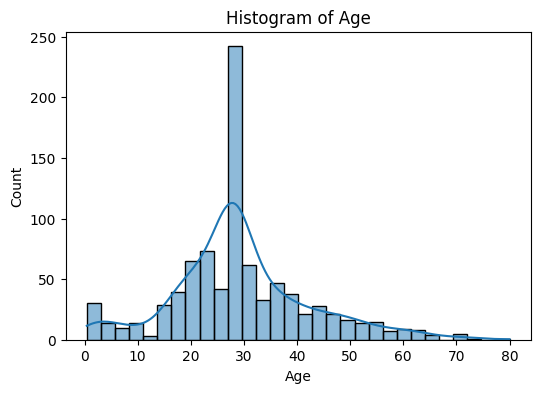

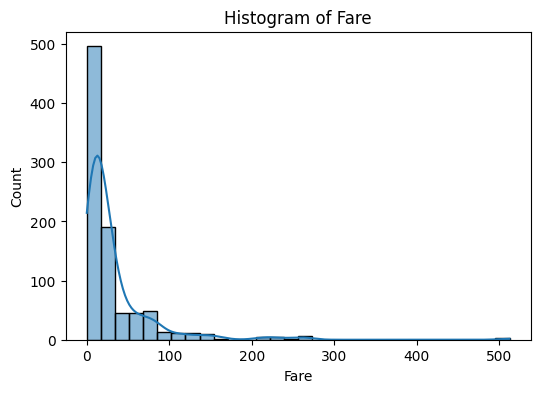

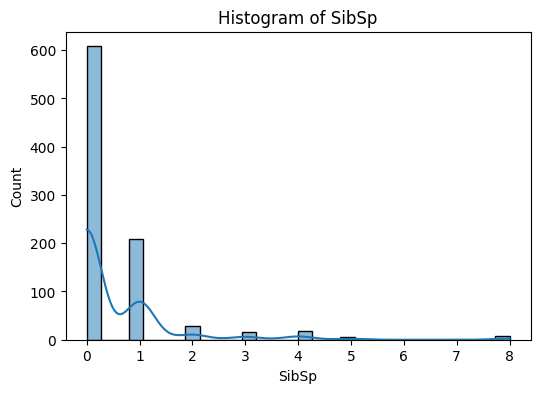

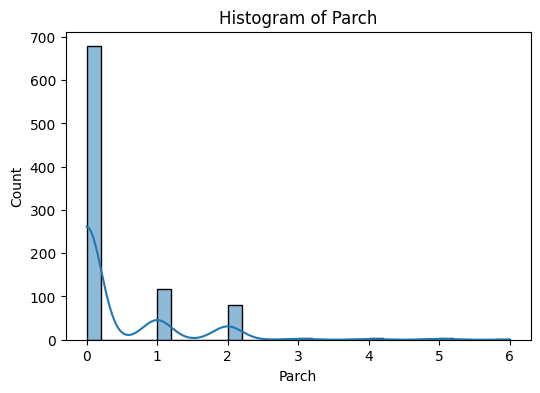

Age      0.510245
Fare     4.787317
SibSp    3.695352
Parch    2.749117
dtype: float64


In [ ]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()
print(df[["Age", "Fare", "SibSp", "Parch"]].skew())



0.3949280095189306


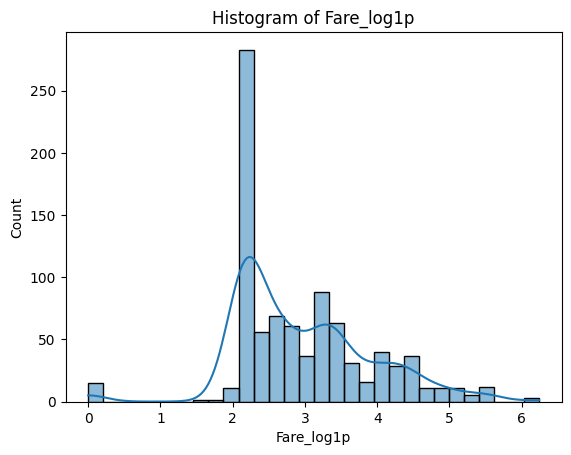

In [ ]:
df["Fare_log1p"] = np.log1p(df["Fare"])
sns.histplot(df["Fare_log1p"], bins=30, kde=True)
plt.title(f"Histogram of Fare_log1p")
print(df["Fare_log1p"].skew())
#After displaying the histograms of the data for all the numerical columns in the dataset, the skewness values ​​are computed. The Fare column was seen to have the most skewness at 4.787317. Hence, the Log transformation using the np.log1p() function was applied to the Fare column to decrease the skewness. Finally, the distribution was displayed before and after the transformation. After applying the transformation to the Fare column, the skewness value was seen to decrease significantly to 0.3949280095189306. Thus, the distribution was seen to be more balanced and less skewed compared to the original form before the transformation.

In [ ]:


df["Age_group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 60, 120],
    labels=["Child", "Teen", "Adult", "Old"],
    right=False
)

df["Age_group"].value_counts()
#I used the function `pd.cut()` to divide the 'Age' column into four groups. This function is used to convert numerical data into categorical data that is easier to analyze. I used simple boundaries such as 'Child,' 'Teen,' 'Adult,' and 'Old,' so that the data is shifted from its original value to its respective category based on its age group. This is similar to data preprocessing techniques used to prepare data for modeling or statistical purposes.

,count
Age_group,
Adult,752
Child,68
Teen,45
Old,26


In [ ]:
corr = df.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df.drop(columns=to_drop, inplace=True, errors='ignore')
print("Dropped:", to_drop)
#I computed the correlation matrix for all the numerical columns in the data. I then took the absolute value of the correlation to deal with very high correlations, regardless of their sign. I then kept only the upper triangle of the matrix to avoid duplicate pairs (A,B) and (B,A). I then looked for any pair with very high correlations (|r| > 0.95) and created a list of redundant columns to delete, since they were conveying almost the same information. I then deleted one column from each pair with very high correlations directly from the data frame, which reduced redundancy and multicollinearity, making the feature set cleaner and more efficient.

Dropped: ['Age_std', 'Fare_std']


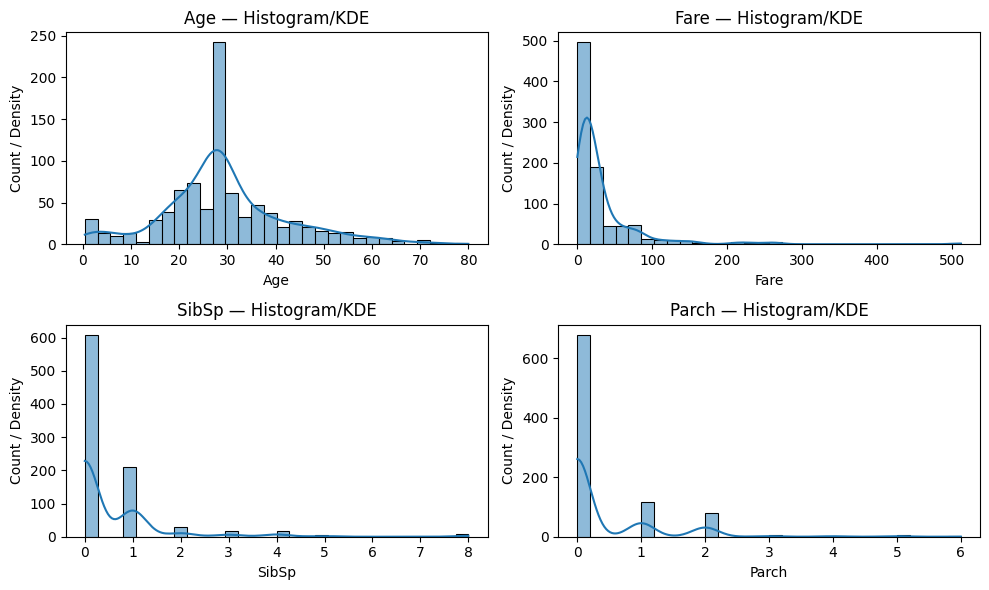

In [ ]:
features = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
for ax, col in zip(axes, features):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"{col} — Histogram/KDE")
    ax.set_xlabel(col); ax.set_ylabel("Count / Density")
plt.tight_layout()
plt.show()
#I plotted a histogram with a density curve (Histogram + KDE) for at least three numerical columns of data (Age, Fare, SibSp, etc.), which gave me an idea about the shape of the distribution. I noticed that the distribution for the Age column was slightly skewed to the right, somewhat symmetric; the Fare column was very skewed to the right with a long tail, which explains the large values in this column. The columns SibSp and Parch were also skewed to the right since there were many zeros or small numbers in these columns, and large values were not very common.


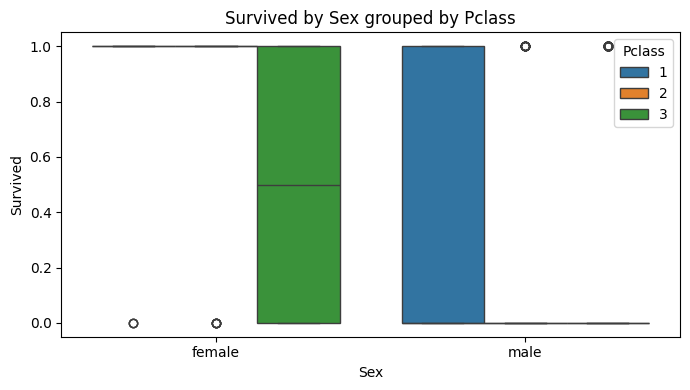

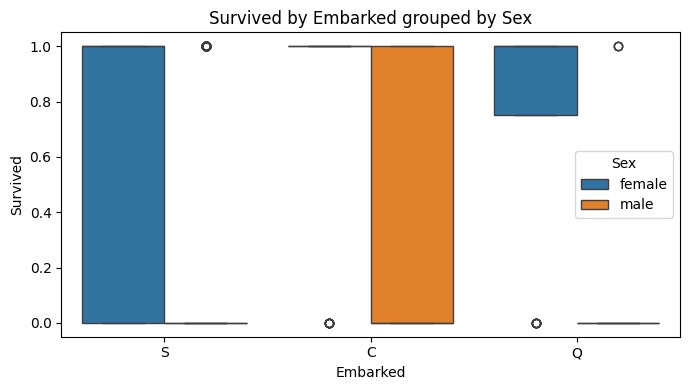

In [ ]:

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Sex", y="Survived", hue="Pclass")
plt.title("Survived by Sex grouped by Pclass")
plt.tight_layout()
plt.show()
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Embarked", y="Survived", hue="Sex", order=["S","C","Q"])
plt.title("Survived by Embarked grouped by Sex")
plt.tight_layout()
plt.show()
#I completed the “Grouped boxplots” task by drawing grouped boxes to visually compare the target variable, Survived, across at least two classification classes. In the first plot, I compared Survived across Sex classes with additional grouping by Pclass(hue) to visualize how, for each Sex class, three boxes representing classes 1, 2, and 3 are distributed. In the second plot, I compared Survived across Embarked classes with additional grouping by Sex and the order of classes S, C, and Q to visualize how, for each Embarked class, two boxes representing classes S, C, and Q are distributed. This type of comparison helps to find patterns and relationships between classes (such as the high median in each group or the small box width, which means little variance in the data). It gives us initial results about how classification variables affect the probability of survival before moving to modeling.


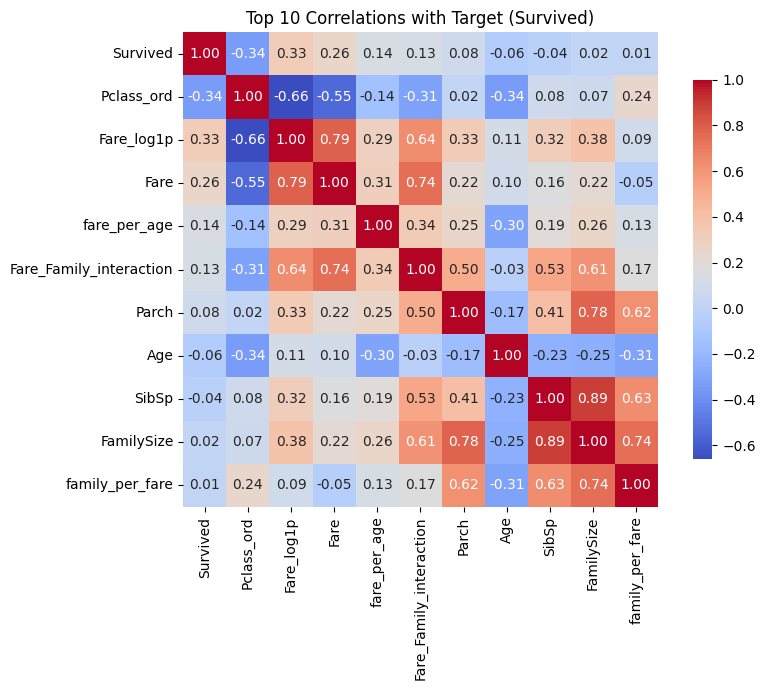

In [ ]:
target = "Survived"
corr_with_target = (
    df.select_dtypes(include=[np.number])
      .corr()[target]
      .drop(labels=[target], errors="ignore")
      .abs()
      .sort_values(ascending=False)
)

top10 = corr_with_target.head(10)
cols = [target] + top10.index.tolist()
cm = df[cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Top 10 Correlations with Target (Survived)")
plt.tight_layout()
plt.show()
#The code first calculates the correlation of each numerical feature with the "survived" objective, then ranks these correlations by absolute strength from highest to lowest, limiting itself to the 10 strongest. It then makes a small correlation matrix including "survived" and these 10 features, and plots a heatmap for it with balanced color for the zeros and clear indication of the correlation in each cell. The effect is a nicely ordered chart that immediately tells you at a glance which features have the strongest correlation with survival, with positive meaning strong correlation in that direction, negative meaning the opposite, and clear labels and axes for ease of reading.



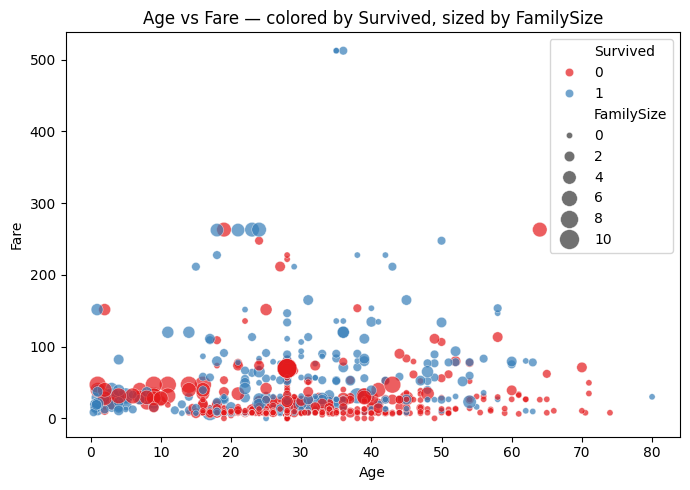

In [ ]:

if "FamilySize" not in df.columns:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df, x="Age", y="Fare",
    hue="Survived",
    size="FamilySize",
    sizes=(20, 200), alpha=0.7, palette="Set1"
)

plt.title("Age vs Fare — colored by Survived, sized by FamilySize")
plt.tight_layout()
plt.show()
#I developed a scatter plot to graphically describe the direct relationship between two numerical variables. These two numerical variables are Age and Fare. However, I included a third variable by varying the color of the scatter plot to represent the variable Survivor to show the difference between those who survived and those who did not. I further included another variable by varying the dot sizes to represent FamilySize. The rationale for this plot is to graphically describe the fundamental relationship between Age and Fare while incorporating other information within the same graph. This will enable one to identify clear patterns, such as the concentration of survivors in a particular area or their differences from non-survivors.


In [ ]:
group_mean = df.groupby("Sex")["Survived"].mean()
print(group_mean)

print("\nHighest group:", group_mean.idxmax(), group_mean.max())
print("Lowest group:", group_mean.idxmin(), group_mean.min())
#I used the `groupby` function to find the survival rate for each category under one of the taxonomic variables. I grouped the data by category and then found the average to determine the survival rate for each group. After getting the results, I was able to identify which group had the highest survival rate and which had the lowest, thus understanding the direct and clear effect of the taxonomic variable on the survival rate.

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Highest group: female 0.7420382165605095
Lowest group: male 0.18890814558058924


/tmp/ipykernel_1351/3030871823.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mean = df.groupby("Sex")["Survived"].mean()


In [ ]:
#Histogram+KDE  Age This feature has an unimodal distribution with a clear peak centered between 20 to 40 years, with only slight skewing to the right (Skew ≈ 0.51). This means that extremely high ages are not very common. Hence, we can safely assume this feature to be model-ready without any transformation. Histogram+KDE  Fare Fare has a strongly right-skewed distribution with most values centered below 50, except for those corresponding to higher classes, which are spread out to very high values. After applying the log1p transformation, the distribution becomes much more balanced (from skewness 4.7873 to 0.3949). Hence, we can safely assume this feature to be model-ready after applying the transformation. Histogram+KDE  SibSp This feature has a very high concentration between 0 and 1, with a long tail to the right (Skew ≈ 3.70). Hence, it can be safely assumed that most passengers were not accompanied by large numbers of siblings/spouses. Histogram+KDE  Parch Similar to the SibSp feature, this feature has a very high concentration at 0 with a strongly right-skewed distribution (Skew ≈ 2.75). Hence, it can be safely assumed that most passengers were not accompanied by their parents/children Grouped Boxplot — Survived by Sex (hue = Pclass)
# Grouped boxplots reveal that the central tendency of survival is higher for one sex group, but class remains a significant factor across the groups. First class has a higher survival rate compared to the second and third class across the board. Grouped Boxplot — Survived by Embarked (hue = Sex) Overall, the C group has a higher median survival compared to the S group and the Q group. In one sex group, C is significantly higher. In the other sex group, the S group is the lowest. Q is the middle group. There is a difference in the medians and the spread. However, the sample size may impact the stability of the results. Correlation Heatmap — Top 10 with Survived Pclass is the strongest negative correlation with the survival of the passenger. Fare and Fare_log1p have the next strongest correlation with the survival of the passenger. Age is the next strongest correlation. Family-related factors, SibSp, Parch, FamilySize, have the weakest correlation with the survival of the passenger. There is redundancy among the fare-related factors..
#Scatter Plot - Age vs Fare (hue = Survived, size = FamilySize) Survivors seem to be more common at higher fares and somewhat younger ages, though not exclusively. Non-survivors, on the other hand, seem to be clustered at lower fares across a wide range of ages. Larger points, or rather FamilySizes, seem to dominate the low fare region with lower survival rates.

In [ ]:

y = df["Survived"].to_numpy(dtype=float)

mean_surv = np.sum(y) / y.size
std_surv  = np.sqrt(np.sum((y - mean_surv)**2) / (y.size - 1))

print("Mean (Survived):", mean_surv)
print("Std  (Survived) [sample]:", std_surv)
#I transformed the Survived column into a NumPy matrix and then calculated the mean manually by summing up the values and then dividing by the number of values. Then, I calculated the sample standard deviation without using pandas.mean(); this was achieved by subtracting the mean from each value, squaring the resulting values, summing them up, and then dividing by n−1n−1n−1 to get the sample variance. Finally, I got the standard deviation by using the power of 0.5 (raising the variance to the power of 0.5 instead of using the square root symbol). This way, I solely depended on NumPy vector operations (addition/subtraction/squaring/raising to the power) to get the speed and accuracy, as required in the methodology for manually calculating statistics on matrices.

Mean (Survived): 0.3838383838383838
Std  (Survived) [sample]: 0.4865924542648575


In [ ]:
num_cols = ["Age", "Fare"]
X_train = df.loc[train_idx, num_cols].to_numpy(dtype=float)

mu = X_train.mean(axis=0)
sd = X_train.std(axis=0, ddof=0)
X_all  = df[num_cols].to_numpy(dtype=float)
Z_man   = (X_all - mu) / sd
df[["Age_std_manual", "Fare_std_manual"]] = Z_man

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df.loc[train_idx, num_cols])
scaled_all = scaler.transform(df[num_cols])
df[["Age_std", "Fare_std"]] = pd.DataFrame(
    scaled_all, columns=["Age_std", "Fare_std"], index=df.index
)

diff = df[["Age_std", "Fare_std"]].to_numpy() - Z_man
print("Max abs diff per column (Age, Fare):", np.max(np.abs(diff), axis=0))
print(df[["Age", "Age_std", "Age_std_manual", "Fare", "Fare_std", "Fare_std_manual"]].head(10))
#You have successfully calculated the mean and vertical skew of the columns Age and Fare based on the training data only. After that, you used this information to apply manual standardization to the entire dataset based on the formula (X - mean) / std. Finally, you used the StandardScaler to standardize the columns correctly and then compared the results of the manual standardization to the results of using the StandardScaler. It was clear that the results were almost equal to zero, which means that the task was done correctly.

Max abs diff per column (Age, Fare): [0. 0.]
    Age   Age_std  Age_std_manual     Fare  Fare_std  Fare_std_manual
0  22.0 -0.554214       -0.554214   7.2500 -0.487864        -0.487864
1  38.0  0.676666        0.676666  71.2833  0.745133         0.745133
2  26.0 -0.246494       -0.246494   7.9250 -0.474867        -0.474867
3  35.0  0.445876        0.445876  53.1000  0.395003         0.395003
4  35.0  0.445876        0.445876   8.0500 -0.472460        -0.472460
5  28.0 -0.092634       -0.092634   8.4583 -0.464598        -0.464598
6  54.0  1.907546        1.907546  51.8625  0.371175         0.371175
7   2.0 -2.092813       -2.092813  21.0750 -0.221656        -0.221656
8  27.0 -0.169564       -0.169564  11.1333 -0.413089        -0.413089
9  14.0 -1.169653       -1.169653  30.0708 -0.048437        -0.048437


In [ ]:

num = df.select_dtypes(include=[np.number])
num2 = num.dropna()
hi = num2.loc[num2['Fare'].idxmax()]
lo = num2.loc[num2['Fare'].idxmin()]
a = hi.values
b = lo.values
cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
cos
print("Highest Fare vector:\n", a)
print("Lowest Fare vector:\n", b)
print("Cosine Similarity =", cos)



Highest Fare vector:
 [2.59000000e+02 1.00000000e+00 3.50000000e+01 0.00000000e+00
 0.00000000e+00 5.12329200e+02 0.00000000e+00 1.46379771e+01
 0.00000000e+00 0.00000000e+00 5.12329200e+02 6.24091735e+00
 4.45876240e-01 9.23772417e+00 4.45876240e-01 9.23772417e+00]
Lowest Fare vector:
 [180.           0.          36.           0.           0.
   0.           2.           0.           0.           0.
   0.           0.           0.52280622  -0.62746737   0.52280622
  -0.62746737]
Cosine Similarity = 0.3384140909859656


In [ ]:
hq = df[df["Pclass"] == 1]
threshold = 100
hq_above = hq[hq["Fare"] > threshold]
fraction = len(hq_above) / len(hq)
print(fraction)
percentage = fraction * 100
print(f"{percentage:.2f}%")


0.24537037037037038
24.54%
